In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
print("Shape (rows, columns):", df.shape)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nColumn data types:")
print(df.dtypes)

Shape (rows, columns): (891, 12)

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Column data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


## First Look at the Titanic Dataset

This dataset has 891 rows and 12 columns describing passengers aboard the Titanic. The target column is `Survived` (0 = died, 1 = survived).

`Age` has 177 missing values, and `Cabin` is missing a huge chunk of data (687 out of 891 rows) — it will likely need to be dropped or heavily reworked later. `Embarked` is only missing 2 values, so that's easy to fix.

Numerical columns include `Age`, `Fare`, `SibSp`, and `Parch`, while categorical columns include `Sex`, `Embarked`, `Pclass`, and `Ticket`.

Overall the dataset looks fairly clean and manageable, but missing values (especially in `Cabin` and `Age`) will need to be handled before any modeling.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Fill missing Age with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with the most common value (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column entirely - too many missing values (77%)
df = df.drop('Cabin', axis=1)

# Confirm no more missing values (except Cabin which we dropped)
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Handling Missing Values

- **Age**: Filled missing values with the **median** age instead of the mean, since median is more robust to outliers (a few very old or very young passengers won't skew it).
- **Embarked**: Filled the 2 missing values with the **mode** (most frequent port), since it's a categorical column and only 2 values were missing — a safe, low-impact choice.
- **Cabin**: Dropped entirely, since 77% of its values were missing. Trying to fill that much missing data would introduce more noise than signal.

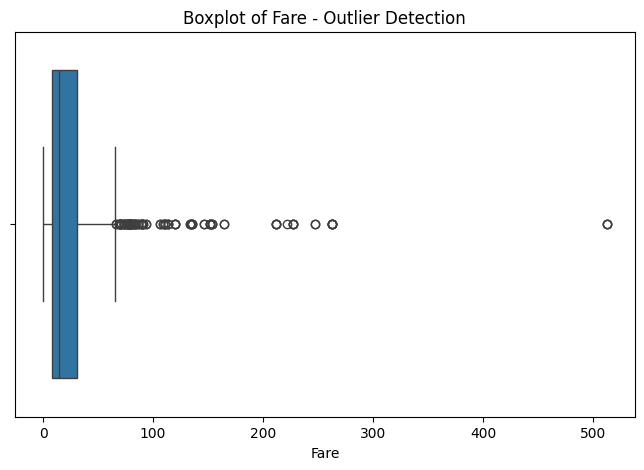

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Fare'])
plt.title('Boxplot of Fare - Outlier Detection')
plt.show()

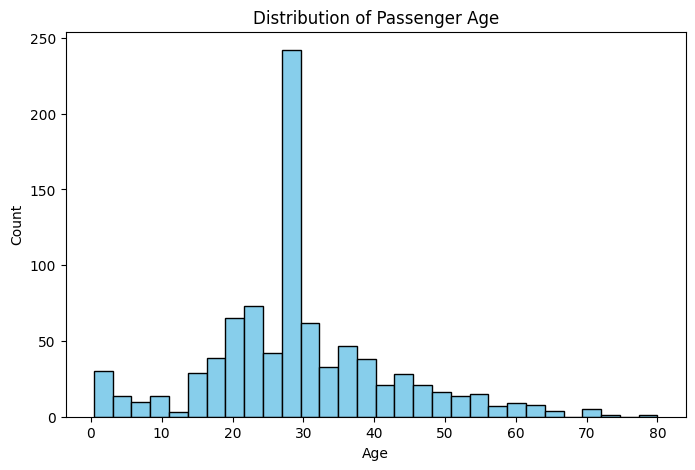

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['Age'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

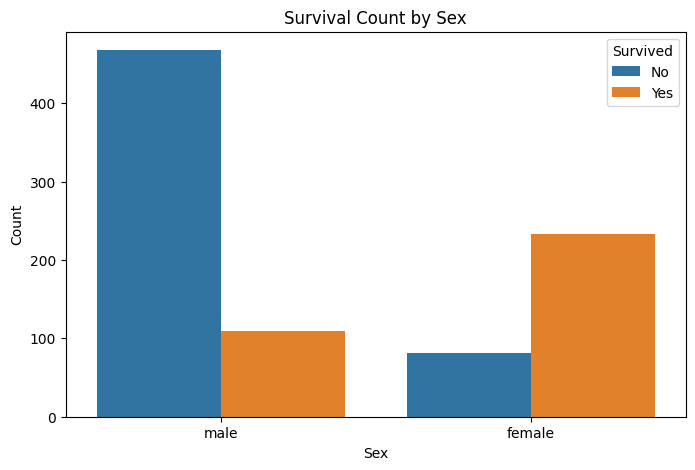

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Count by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

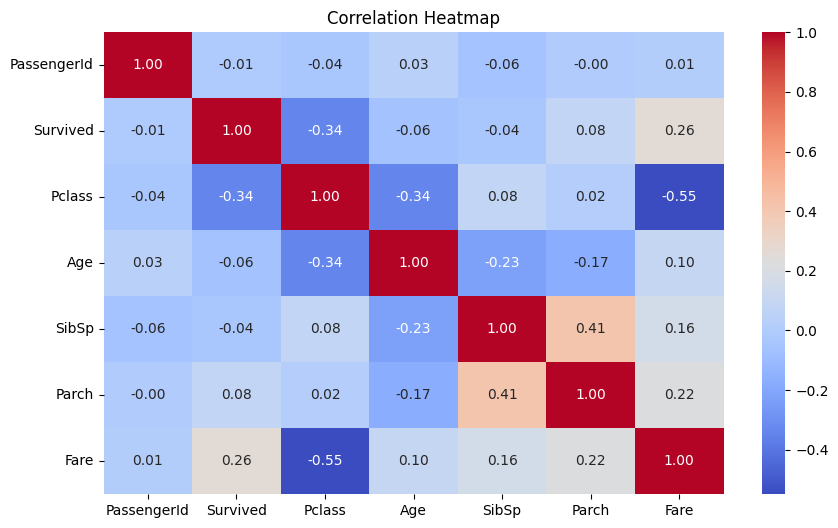

In [ ]:
plt.figure(figsize=(10, 6))
# Only numeric columns can be correlated
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Which Feature Most Affects Survival?

Based on the correlation heatmap, `Pclass` (passenger class) has the strongest correlation with `Survived` at -0.34. The negative sign means lower class numbers (1st class) were associated with higher survival — likely because 1st class passengers had cabins closer to lifeboats and were prioritized during evacuation.

`Fare` also shows a positive correlation with survival (0.26), which makes sense since higher fares are closely tied to `Pclass` — passengers who paid more typically held higher-class tickets.

In [ ]:
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
df_encoded.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,True,False,True


In [ ]:
X = df_encoded.drop(['Survived', 'Name', 'Ticket', 'PassengerId'], axis=1)
y = df_encoded['Survived']

X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (712, 8)
Test set size: (179, 8)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 81.01%


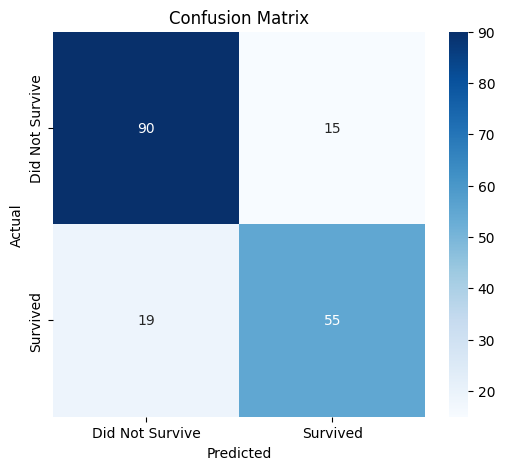

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Did Not Survive', 'Survived'], yticklabels=['Did Not Survive', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Confusion Matrix Explanation

The confusion matrix shows how well the model's predictions matched reality on the test set:

- **90** passengers who did not survive were correctly predicted as "Did Not Survive"
- **55** passengers who survived were correctly predicted as "Survived"
- **15** passengers who did not survive were incorrectly predicted as "Survived" (false positives)
- **19** passengers who survived were incorrectly predicted as "Did Not Survive" (false negatives)

Out of 179 test passengers, the model correctly predicted 145 (90 + 55), giving an accuracy of about **81%**. The model is slightly better at identifying passengers who did not survive than those who did, since it made more errors on the "Survived" class (19 false negatives vs 15 false positives).

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

                 precision    recall  f1-score   support

Did Not Survive       0.83      0.86      0.84       105
       Survived       0.79      0.74      0.76        74

       accuracy                           0.81       179
      macro avg       0.81      0.80      0.80       179
   weighted avg       0.81      0.81      0.81       179



## Why Accuracy Alone Can Be Misleading

Accuracy only tells us the overall percentage of correct predictions, but it hides how a model performs on each individual class. If a dataset is imbalanced (e.g., 90% of passengers didn't survive), a model could predict "Did Not Survive" every single time and still score 90% accuracy — despite being completely useless at identifying survivors. Precision and Recall solve this by showing, for each class, how many predicted positives were actually correct (Precision) and how many actual positives were successfully caught (Recall). F1-score balances the two. This gives a much more honest picture of model quality, especially for the minority class.

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'C': 1, 'solver': 'liblinear'}
Best cross-validation accuracy: 0.7962966610853935


In [23]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

from sklearn.metrics import accuracy_score
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Model Accuracy: {tuned_accuracy:.2%}")

print(classification_report(y_test, y_pred_tuned, target_names=['Did Not Survive', 'Survived']))

Tuned Model Accuracy: 78.21%
                 precision    recall  f1-score   support

Did Not Survive       0.79      0.85      0.82       105
       Survived       0.76      0.69      0.72        74

       accuracy                           0.78       179
      macro avg       0.78      0.77      0.77       179
   weighted avg       0.78      0.78      0.78       179



In [24]:
comparison = pd.DataFrame({
    'Model': ['Original Logistic Regression', 'Tuned Logistic Regression'],
    'Accuracy': [accuracy_score(y_test, y_pred), tuned_accuracy]
})
comparison

,Model,Accuracy
0,Original Logistic Regression,0.810056
1,Tuned Logistic Regression,0.782123
